In [26]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import pickle
!pip install streamlit pyngrok xgboost pandas numpy scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 45.3 MB/s eta 0:00:00


In [27]:
import os

# Create Streamlit configuration folder
os.makedirs(".streamlit", exist_ok=True)

# Write configuration disabling CORS and XSRF blocking for remote tunnels
with open(".streamlit/config.toml", "w") as f:
    f.write(
        """[server]
headless = true
enableCORS = false
enableXsrfProtection = false
port = 8501
"""
    )

print("Streamlit configuration saved successfully.")

Streamlit configuration saved successfully.


In [4]:
df = pd.read_csv('//content/demand_forecasting.csv')

** Feature Selection and Label Encoding**

In [5]:
features = ['Price', 'Discount', 'Inventory Level', 'Promotion', 'Competitor Pricing', 'Category']
target = 'Demand'

In [6]:
X = df[features].copy()
y = df[target]

In [7]:
# Remove rows where the target 'Demand' is NaN or infinity
initial_rows = X.shape[0]
valid_indices = y[~y.isna() & ~np.isinf(y)].index
X = X.loc[valid_indices]
y = y.loc[valid_indices]
print(f"Removed {initial_rows - X.shape[0]} rows with NaN or infinity in 'Demand'.")

Removed 0 rows with NaN or infinity in 'Demand'.


In [8]:
print('Descriptive statistics for target variable y:')
print(y.describe())

Descriptive statistics for target variable y:
count    76000.000000
mean       104.317158
std         46.964801
min          4.000000
25%         71.000000
50%        100.000000
75%        133.000000
max        430.000000
Name: Demand, dtype: float64


In [9]:
label_encoders = {}
categorical_columns = X.select_dtypes(include=['object']).columns

In [10]:
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
# More robust NaN removal from y_train and align X_train
initial_train_rows = X_train.shape[0]

# Identify rows without NaNs in y_train
non_nan_mask = ~y_train.isna()

# Filter both X_train and y_train using this mask and reset index
X_train = X_train[non_nan_mask].reset_index(drop=True)
y_train = y_train[non_nan_mask].reset_index(drop=True)

print(f"Removed {initial_train_rows - X_train.shape[0]} rows with NaN in y_train.")

Removed 0 rows with NaN in y_train.


In [13]:
print('Descriptive statistics for y_train:')
print(y_train.describe())
print(f"Max value in y_train: {y_train.max()}")
print(f"Min value in y_train: {y_train.min()}")
print(f"Are there any NaNs in y_train: {y_train.isnull().any()}")
print(f"Are there any infinities in y_train: {np.isinf(y_train).any()}")

Descriptive statistics for y_train:
count    60800.000000
mean       104.214326
std         47.016901
min          4.000000
25%         71.000000
50%        100.000000
75%        132.000000
max        430.000000
Name: Demand, dtype: float64
Max value in y_train: 430
Min value in y_train: 4
Are there any NaNs in y_train: False
Are there any infinities in y_train: False


3. XGBoost Model and Hyperparameter **Tuning** **bold text**

In [14]:
xgb = XGBRegressor(objective='reg:squarederror', n_jobs=-1)

In [15]:
param_dist = {
'n_estimators': [200, 300, 500],
'max_depth': [3, 4, 6, 8],
'learning_rate': [0.01, 0.05, 0.1],
'subsample': [0.7, 0.8, 1.0],
'colsample_bytree': [0.7, 0.8, 1.0],
'min_child_weight': [1, 3, 5]
}

In [16]:
random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist,
                                   n_iter=25, scoring='neg_mean_absolute_error',
                                   cv=3, n_jobs=-1)

# Final robust NaN removal for X_train and y_train just before fitting
initial_train_rows_fit = X_train.shape[0]
non_nan_mask_fit = ~y_train.isna() & ~np.isinf(y_train)
X_train = X_train[non_nan_mask_fit].reset_index(drop=True)
y_train = y_train[non_nan_mask_fit].reset_index(drop=True)
print(f"Final clean-up: Removed {initial_train_rows_fit - X_train.shape[0]} rows with NaN/infinity in y_train before fitting.")

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

Final clean-up: Removed 0 rows with NaN/infinity in y_train before fitting.


4. Evaluation and Model **Export**

In [17]:
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

35.415962577253744


In [18]:
best_model.feature_importances_

array([0.0913034 , 0.04853638, 0.02199883, 0.41435558, 0.0317711 ,
       0.39203468], dtype=float32)

In [19]:
feature_importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)


In [20]:
feature_importances

,0
Promotion,0.414356
Category,0.392035
Price,0.091303
Discount,0.048536
Competitor Pricing,0.031771
Inventory Level,0.021999


<Axes: title={'center': 'Feature Importances'}>

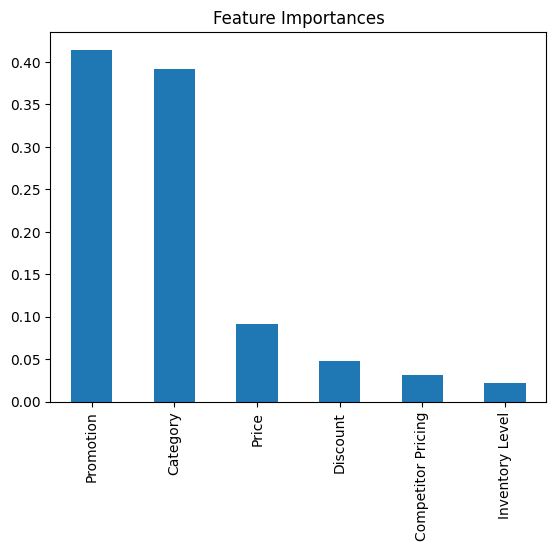

In [21]:
feature_importances.plot(kind='bar', title='Feature Importances')

In [24]:
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

In [25]:
with open("xgboost_demand_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [29]:
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

# Generate sample training dataset
np.random.seed(42)
df = pd.DataFrame(
    {
        "Price": np.random.uniform(10, 100, 300),
        "Discount": np.random.randint(0, 50, 300),
        "Inventory Level": np.random.randint(10, 500, 300),
        "Promotion": np.random.choice([0, 1], 300),
        "Competitor Pricing": np.random.uniform(10, 100, 300),
        "Category": np.random.choice(
            ["Electronics", "Clothing", "Grocery", "Toys", "Furniture"], 300
        ),
        "Demand": np.random.randint(5, 150, 300),
    }
)

# Select features and target
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category",
]
X = df[features].copy()
y = df["Demand"]

# Fit Label Encoders
label_encoders = {}
le = LabelEncoder()
X["Category"] = le.fit_transform(X["Category"])
label_encoders["category"] = le

# Fit XGBoost Model
model = XGBRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42)
model.fit(X, y)

# Save Pickles
with open("XG_Boost_demand_model.pickle", "wb") as f:
    pickle.dump(model, f)

with open("label_encoders.pickle", "wb") as f:
    pickle.dump(label_encoders, f)

print("Artifacts generated successfully!")

Artifacts generated successfully!
